<a href="https://colab.research.google.com/github/ManyaGupta23/Quantium-Data-Analytics-Project/blob/main/Quantium_Task2_Store_Trial_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Importing Libraries and Loading dataset**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("QVI_data.csv")

#*Checking Structure*

In [ ]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246740 entries, 0 to 246739
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   DATE              246740 non-null  object 
 1   STORE_NBR         246740 non-null  int64  
 2   LYLTY_CARD_NBR    246740 non-null  int64  
 3   TXN_ID            246740 non-null  int64  
 4   PROD_NBR          246740 non-null  int64  
 5   PROD_NAME         246740 non-null  object 
 6   PROD_QTY          246740 non-null  int64  
 7   TOT_SALES         246740 non-null  float64
 8   PACK_SIZE         246740 non-null  int64  
 9   BRAND             246740 non-null  object 
 10  LIFESTAGE         246740 non-null  object 
 11  PREMIUM_CUSTOMER  246740 non-null  object 
dtypes: float64(1), int64(6), object(5)
memory usage: 22.6+ MB


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,Natural Chip Co,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175,CCs,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170,Smiths,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175,Smiths,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150,Kettle,MIDAGE SINGLES/COUPLES,Budget


In [ ]:
import pandas as pd

df["DATE"] = pd.to_datetime(df["DATE"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246740 entries, 0 to 246739
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   DATE              246740 non-null  datetime64[ns]
 1   STORE_NBR         246740 non-null  int64         
 2   LYLTY_CARD_NBR    246740 non-null  int64         
 3   TXN_ID            246740 non-null  int64         
 4   PROD_NBR          246740 non-null  int64         
 5   PROD_NAME         246740 non-null  object        
 6   PROD_QTY          246740 non-null  int64         
 7   TOT_SALES         246740 non-null  float64       
 8   PACK_SIZE         246740 non-null  int64         
 9   BRAND             246740 non-null  object        
 10  LIFESTAGE         246740 non-null  object        
 11  PREMIUM_CUSTOMER  246740 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(6), object(4)
memory usage: 22.6+ MB


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246740 entries, 0 to 246739
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   DATE              246740 non-null  datetime64[ns]
 1   STORE_NBR         246740 non-null  int64         
 2   LYLTY_CARD_NBR    246740 non-null  int64         
 3   TXN_ID            246740 non-null  int64         
 4   PROD_NBR          246740 non-null  int64         
 5   PROD_NAME         246740 non-null  object        
 6   PROD_QTY          246740 non-null  int64         
 7   TOT_SALES         246740 non-null  float64       
 8   PACK_SIZE         246740 non-null  int64         
 9   BRAND             246740 non-null  object        
 10  LIFESTAGE         246740 non-null  object        
 11  PREMIUM_CUSTOMER  246740 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(6), object(4)
memory usage: 22.6+ MB


#*Creating year month column*

In [ ]:
df["YEARMONTH"] = df["DATE"].dt.year * 100 + df["DATE"].dt.month

In [ ]:
df[["DATE", "YEARMONTH"]].head()

,DATE,YEARMONTH
0,2018-10-17,201810
1,2019-05-14,201905
2,2019-05-20,201905
3,2018-08-17,201808
4,2018-08-18,201808


#Verifying all months are Unique

In [ ]:
print(df["YEARMONTH"].unique())

[201810 201905 201808 201906 201809 201902 201903 201811 201904 201807
 201901 201812]


#**Monthly Performance Metrics**

In [ ]:
monthly_metrics = (
    df.groupby(["STORE_NBR", "YEARMONTH"])
      .agg(
          TOT_SALES=("TOT_SALES", "sum"),
          N_CUSTOMERS=("LYLTY_CARD_NBR", "nunique"),
          N_TXNS=("TXN_ID", "nunique")
      )
      .reset_index()
)

monthly_metrics["AVG_TXN_PER_CUSTOMER"] = (
    monthly_metrics["N_TXNS"] / monthly_metrics["N_CUSTOMERS"]
)

monthly_metrics.head()

,STORE_NBR,YEARMONTH,TOT_SALES,N_CUSTOMERS,N_TXNS,AVG_TXN_PER_CUSTOMER
0,1,201807,188.9,47,49,1.042553
1,1,201808,168.4,41,41,1.000000
2,1,201809,268.1,57,59,1.035088
3,1,201810,175.4,39,40,1.025641
4,1,201811,184.8,44,45,1.022727


In [ ]:
monthly_metrics.shape

(3165, 6)

In [ ]:
monthly_metrics.columns

Index(['STORE_NBR', 'YEARMONTH', 'TOT_SALES', 'N_CUSTOMERS', 'N_TXNS',
       'AVG_TXN_PER_CUSTOMER'],
      dtype='object')

#**Chcking Stores**

In [ ]:
store_counts = monthly_metrics.groupby("STORE_NBR")["YEARMONTH"].nunique()

print(store_counts.describe())

count    271.000000
mean      11.678967
std        1.745969
min        1.000000
25%       12.000000
50%       12.000000
75%       12.000000
max       12.000000
Name: YEARMONTH, dtype: float64


In [ ]:
complete_stores = store_counts[store_counts == 12].index

print(f"Number of complete stores: {len(complete_stores)}")

Number of complete stores: 259


#Creating pre trial dataset

In [ ]:
pre_trial = monthly_metrics[monthly_metrics["YEARMONTH"] < 201902]

pre_trial.head()

,STORE_NBR,YEARMONTH,TOT_SALES,N_CUSTOMERS,N_TXNS,AVG_TXN_PER_CUSTOMER
0,1,201807,188.9,47,49,1.042553
1,1,201808,168.4,41,41,1.000000
2,1,201809,268.1,57,59,1.035088
3,1,201810,175.4,39,40,1.025641
4,1,201811,184.8,44,45,1.022727


#Checking trial stores

In [ ]:
pre_trial[pre_trial["STORE_NBR"].isin([77, 86, 88])]

,STORE_NBR,YEARMONTH,TOT_SALES,N_CUSTOMERS,N_TXNS,AVG_TXN_PER_CUSTOMER
880,77,201807,268.40,47,51,1.085106
881,77,201808,247.50,46,46,1.000000
882,77,201809,216.80,40,42,1.050000
883,77,201810,194.30,36,37,1.027778
884,77,201811,224.90,39,42,1.076923
885,77,201812,255.20,43,44,1.023256
886,77,201901,188.40,31,35,1.129032
977,86,201807,851.00,94,120,1.276596
978,86,201808,726.85,92,104,1.130435
979,86,201809,855.00,100,120,1.200000


#Keep Only Stores with Complete Pre-Trial Data

The pre-trial period is July 2018 to January 2019, which is 7 months.

In [ ]:
store_months = pre_trial.groupby("STORE_NBR")["YEARMONTH"].nunique()

complete_stores = store_months[store_months == 7].index

pre_trial = pre_trial[pre_trial["STORE_NBR"].isin(complete_stores)]

In [ ]:
print(pre_trial["STORE_NBR"].nunique())

260


#Creating a Function to Find the Best Control Store

In [ ]:
def find_control_store(trial_store, metric="TOT_SALES"):

    trial_data = pre_trial[
        pre_trial["STORE_NBR"] == trial_store
    ][["YEARMONTH", metric]]

    correlations = []

    for store in pre_trial["STORE_NBR"].unique():

        if store == trial_store:
            continue

        control_data = pre_trial[
            pre_trial["STORE_NBR"] == store
        ][["YEARMONTH", metric]]

        merged = pd.merge(
            trial_data,
            control_data,
            on="YEARMONTH",
            suffixes=("_trial", "_control")
        )

        if len(merged) == 7:

            corr = merged[f"{metric}_trial"].corr(
                merged[f"{metric}_control"]
            )

            correlations.append([store, corr])

    corr_df = pd.DataFrame(
        correlations,
        columns=["STORE_NBR", "Correlation"]
    )

    return corr_df.sort_values(
        "Correlation",
        ascending=False
    )

#Finding Control Store for Store 77

In [ ]:
control77 = find_control_store(77)

control77.head(10)

,STORE_NBR,Correlation
220,233,0.973643
46,50,0.897701
153,162,0.857584
67,71,0.815635
148,157,0.776545
110,119,0.775571
105,113,0.747222
28,30,0.740401
15,17,0.707947
56,60,0.691252


#Finding Control Store for Store 86

In [ ]:
control86 = find_control_store(86)

control86.head(10)

,STORE_NBR,Correlation
146,155,0.869532
123,132,0.842632
246,260,0.827631
129,138,0.796065
5,6,0.781804
106,114,0.750924
255,269,0.747432
209,222,0.741962
52,56,0.735300
157,166,0.729200


In [ ]:
control88 = find_control_store(88)

control88.head(10)

,STORE_NBR,Correlation
150,159,0.938775
84,91,0.911986
194,204,0.871969
0,1,0.842232
227,240,0.817245
57,61,0.777007
74,79,0.771989
212,225,0.735724
154,163,0.713393
6,7,0.698846


## Insight

Using Pearson correlation on pre-trial monthly sales, the most suitable control stores were identified for each trial store.

- Trial Store **77** → Control Store **233** (Correlation = **0.9736**)
- Trial Store **86** → Control Store **155** (Correlation = **0.8695**)
- Trial Store **88** → Control Store **159** (Correlation = **0.9388**)

These control stores exhibited purchasing patterns most similar to the corresponding trial stores during the pre-trial period and were selected for subsequent comparison.

#**Compare Trial vs. Control Stores**

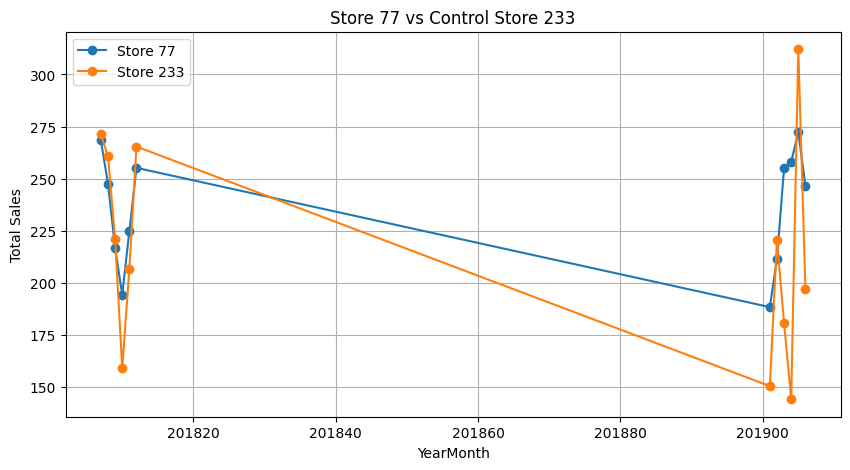

In [ ]:
trial77 = monthly_metrics[
    monthly_metrics["STORE_NBR"].isin([77, 233])
]

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for store in [77, 233]:
    temp = trial77[trial77["STORE_NBR"] == store]

    plt.plot(
        temp["YEARMONTH"],
        temp["TOT_SALES"],
        marker="o",
        label=f"Store {store}"
    )

plt.title("Store 77 vs Control Store 233")
plt.xlabel("YearMonth")
plt.ylabel("Total Sales")
plt.legend()
plt.grid(True)

plt.show()

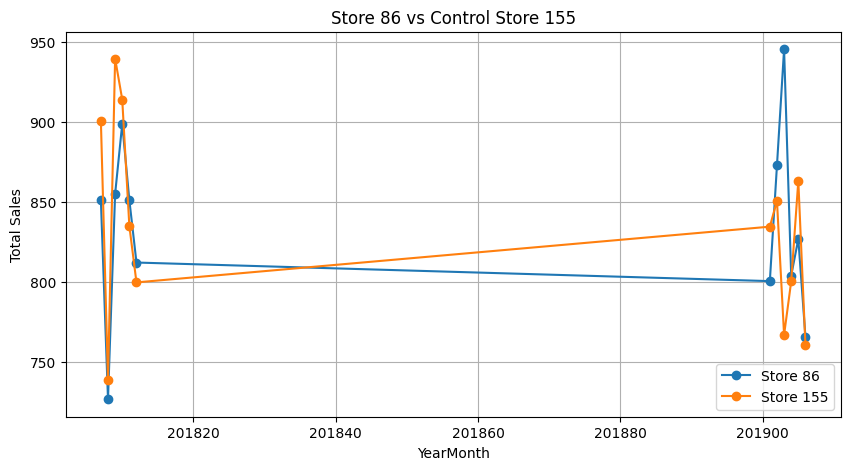

In [ ]:
trial77 = monthly_metrics[
    monthly_metrics["STORE_NBR"].isin([86, 155])
]

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for store in [86, 155]:
    temp = trial77[trial77["STORE_NBR"] == store]

    plt.plot(
        temp["YEARMONTH"],
        temp["TOT_SALES"],
        marker="o",
        label=f"Store {store}"
    )

plt.title("Store 86 vs Control Store 155")
plt.xlabel("YearMonth")
plt.ylabel("Total Sales")
plt.legend()
plt.grid(True)

plt.show()

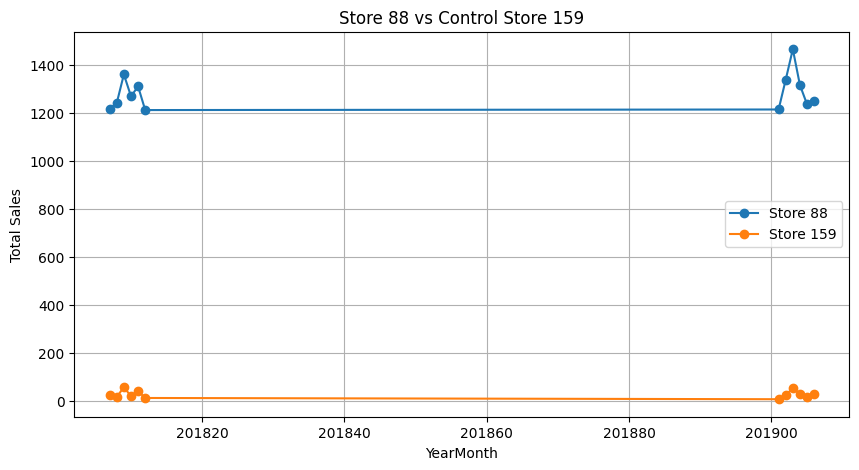

In [ ]:
trial77 = monthly_metrics[
    monthly_metrics["STORE_NBR"].isin([88, 159])
]

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for store in [88, 159]:
    temp = trial77[trial77["STORE_NBR"] == store]

    plt.plot(
        temp["YEARMONTH"],
        temp["TOT_SALES"],
        marker="o",
        label=f"Store {store}"
    )

plt.title("Store 88 vs Control Store 159")
plt.xlabel("YearMonth")
plt.ylabel("Total Sales")
plt.legend()
plt.grid(True)

plt.show()